In [1]:
import os
import mdtraj as md
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
plt.style.use('ggplot')
from rdkit import Chem
from mc_analysis import ALIPHATIC_SCAFFOLD, get_scaffold_dihedrals, best_periodic_shift, get_linker_dihedrals, get_extra_dihedrals, extract_hbond_data
from mc_analysis import extract_scaffold_dihedrals, extract_other_dihedrals, extract_other_dihedrals_acyclic, convergence_curve
from scipy.stats import pearsonr
import parmed as pmd
from tempfile import TemporaryDirectory

## Part 0: paths

Since the full trajectories are not provided in this repository, we set empty paths to trigger reading the data from the `md_data` directory.

The trajectory parsing functions ("extract_xxx") are provided for transparency.

In [2]:
os.makedirs("md_data", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

In [3]:
# macrocycles
solution_dir = ""
complex_dir = ""
# non-macrocyclic scaffold references
acyclic_solution_dir = ""
acyclic_complex_dir = ""

## Part 1: experimental data

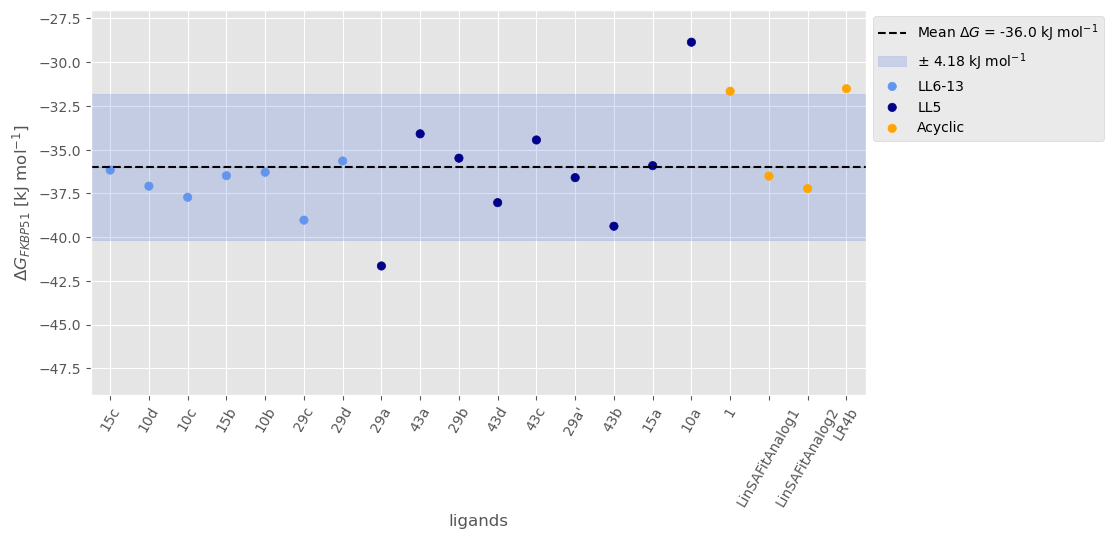

In [4]:
# Load the data
affinity_data = pd.read_csv("../data/affinity_data.csv")
affinity_data.rename(columns={'Unnamed: 0': "i"}, inplace=True)
affinity_data.set_index('Name', inplace=True, drop=True)
ligands = affinity_data.index.to_list()

# Setting up the bar plot
num_elements = len(ligands)
x = np.arange(num_elements)  # the label locations

fig, ax = plt.subplots(figsize=(10, 5))
mean = np.mean(affinity_data["dG_FKBP51 [kJ/mol]"])
one_kcal = 4.184 # kcal/mol to kJ/mol
ax.axhline(y=mean, color='black', linestyle='--', label=rf'Mean $\Delta G$ = {mean:.1f} kJ mol$^{{-1}}$')
ax.fill_between([-1]+list(x)+[max(x)+1], mean, mean+one_kcal, color='royalblue', alpha=0.2)
ax.fill_between([-1]+list(x)+[max(x)+1], mean-one_kcal, mean, color='royalblue', alpha=0.2, label=r'$\pm$ 4.18 kJ mol$^{-1}$')
for label in affinity_data.label.unique():
    labelled_data = affinity_data.loc[affinity_data.label == label]
    ax.scatter(x[labelled_data["i"]], labelled_data["dG_FKBP51 [kJ/mol]"], c=labelled_data["color"], marker="o", label=label)

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('ligands')
ax.set_ylabel(r'$\Delta G_{FKBP51}$ [kJ mol$^{-1}$]')
ax.set_xticks(x)
ax.set_xticklabels(ligands, rotation=60)
ax.set_ylim(-49,-27)
ax.set_xlim(-0.5, num_elements-0.5)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('../figures/affinities_sorted_by_linker_size.png', bbox_inches='tight')

## Part 2: hydrogen bonds in complex

Reading MD data file md_data/hydrogen_bonds.csv


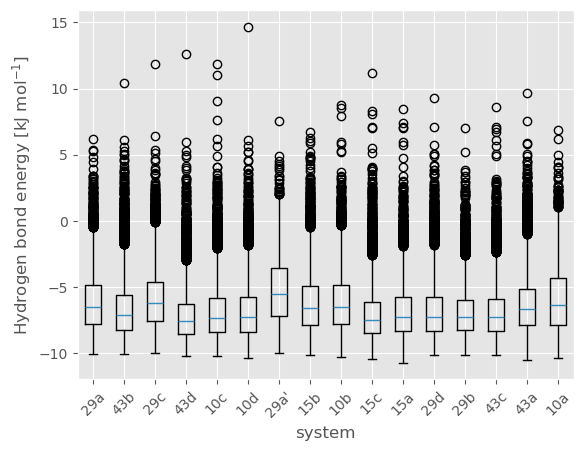

In [5]:
hbond_data = extract_hbond_data(complex_dir, 'md_data/hydrogen_bonds.csv')

systems = hbond_data["system"].unique()
hbond_energy = hbond_data.pivot(index='system', columns='frame', values='energy').values
# Order by affinity
sorted_hbond_energy = hbond_energy[np.argsort(affinity_data["dG_FKBP51 [kJ/mol]"].loc[systems].to_list())]
sorted_systems = affinity_data["dG_FKBP51 [kJ/mol]"].loc[systems].sort_values().index.to_list()
# Plot the average hydrogen bond energy as per system
plt.boxplot(sorted_hbond_energy.T)
plt.xlabel('system')
plt.xticks(range(1, len(sorted_systems)+1), sorted_systems, rotation=45)
plt.ylabel('Hydrogen bond energy [kJ mol$^{-1}$]');

No apparent correlation between the hydrogen bond energy in complex and the affinity -> complex simulation alone isn't enough to explain affinity

Reading MD data file md_data/scaffold_dihedrals_complex.csv
-39.1 < B < 20.9


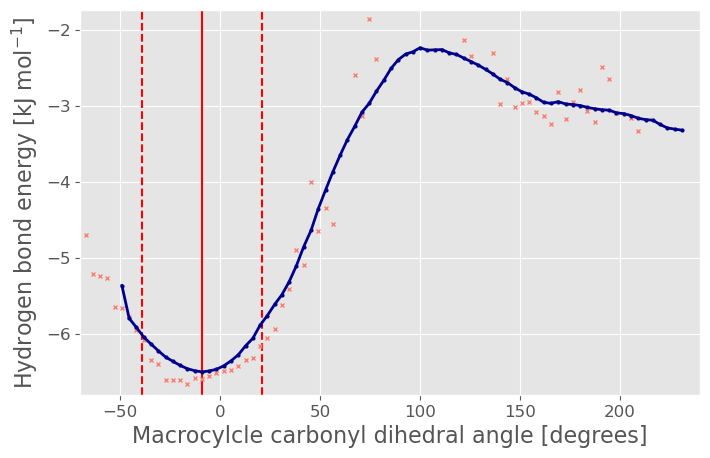

In [6]:
dihedrals_complex = extract_scaffold_dihedrals(complex_dir, 'md_data/scaffold_dihedrals_complex.csv')

angle_B = dihedrals_complex.pivot(index='system', columns='frame', values='angle_1').values
interval = [-100, 260]
angle_B = np.where(angle_B > interval[1], angle_B-360, angle_B)
grid = np.linspace(*interval, 100)
avg_energy_per_angle = []
for i in range(len(grid)-1):
    if len(hbond_energy.flatten()[np.where((angle_B.flatten() > grid[i]) & (angle_B.flatten() < grid[i+1]))]) == 0:
        # There is no single data point in this angle range
        avg_energy_per_angle.append(np.nan)
        continue
    avg_energy_per_angle.append(np.mean(hbond_energy.flatten()[np.where((angle_B.flatten() > grid[i]) & (angle_B.flatten() < grid[i+1]))]))
avg_angle_energies = pd.DataFrame({'angle': grid[:-1], 'energy': avg_energy_per_angle})
# Interpolate NaN values
interpolated = avg_angle_energies['energy'].interpolate()
# Smoothen
interpolated = interpolated.rolling(15, center=True).mean()
plt.figure(figsize=(8, 5))
# Plot raw values
plt.plot(avg_angle_energies['angle'], avg_angle_energies['energy'], marker="x", markersize=3, ls="", color="salmon")
# Plot interpolation
plt.plot(avg_angle_energies['angle'], interpolated, marker=".", markersize=4, linewidth=2, color="darkblue")
min_angle = avg_angle_energies['angle'][interpolated.idxmin()]
print(f"{min_angle-30:.1f} < B < {min_angle+30:.1f}")
# Define the "preorganized" region as a 60 degree window around the minimum
allowed_region = [min_angle-30, min_angle+30]
plt.ylim(np.min(interpolated)-0.3, np.max(interpolated)+0.5)
plt.xlim(-70, 240)
plt.axvline(allowed_region[0], color='red', linestyle='--', zorder=1)
plt.axvline(min_angle, color='red', zorder=1)
plt.axvline(allowed_region[1], color='red', linestyle='--', zorder=1, label='Low energy Hydrogen bond')
plt.xlabel('Macrocylcle carbonyl dihedral angle [degrees]', fontsize=16)
plt.ylabel(r'Hydrogen bond energy [kJ mol$^{-1}$]', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.savefig('../figures/hbond_energy_per_angle.png', bbox_inches='tight')

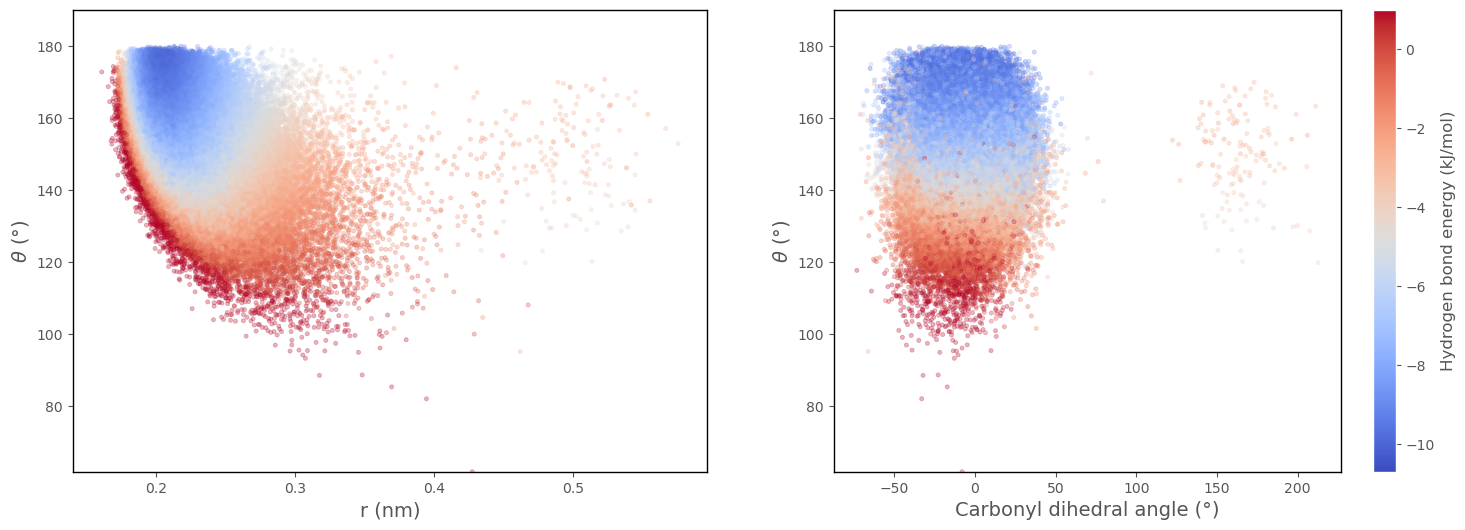

In [7]:
fig, axs = plt.subplots(ncols=2, figsize=(18,6))
hbond_flat = hbond_energy.flatten()
theta_flat = hbond_data.pivot(index='system', columns='frame', values='angle').values.flatten()
d_flat_major = hbond_data.pivot(index='system', columns='frame', values='distance').values.flatten()
axs[0].scatter(d_flat_major, theta_flat, c=np.where(hbond_flat > 1, 1, hbond_flat), marker=".", cmap='coolwarm', alpha=0.3)
axs[0].grid(False)
axs[0].set_facecolor('white')
axs[0].spines[['left', 'bottom', 'right', 'top']].set_color('black')
axs[0].set_ylim(min(theta_flat), 190)
axs[0].set_xlabel('r (nm)', fontsize=14)
axs[0].set_ylabel(r'$\theta$ (°)', fontsize=14)
axs[1].scatter(angle_B.flatten(), theta_flat, c=np.where(hbond_flat > 1, 1, hbond_flat), marker=".", cmap='coolwarm', alpha=0.3)
axs[1].grid(False)
axs[1].set_facecolor('white')
axs[1].spines[['left', 'bottom', 'right', 'top']].set_color('black')
axs[1].set_ylim(min(theta_flat), 190)
axs[1].set_xlabel('Carbonyl dihedral angle (°)', fontsize=14)
axs[1].set_ylabel(r'$\theta$ (°)', fontsize=14)
cbar = plt.colorbar(axs[1].collections[0], ax=axs[1])
cbar.solids.set(alpha=1)
cbar.set_label('Hydrogen bond energy (kJ/mol)')

## Part 3: Solvent conformation correlation

In [8]:
dih = extract_scaffold_dihedrals(solution_dir, 'md_data/scaffold_dihedrals_solution.csv')
dih_acyclic = extract_scaffold_dihedrals(acyclic_solution_dir, 'md_data/scaffold_dihedrals_solution_acyclic.csv')

#scaffold_dihedrals = pd.concat([pd.read_csv('md_data/scaffold_dihedrals_solution.csv', index_col=0), pd.read_csv('md_data/scaffold_dihedrals_solution_acyclic.csv', index_col=0)])
scaffold_dihedrals = pd.concat([dih, dih_acyclic])
systems = scaffold_dihedrals["system"].unique()

allowed_B = np.array([False] * 360)
for i in range(360):
    allowed_B[i] = i > allowed_region[0] + 360 or i < allowed_region[1] # +360 to the lower bound since it's negative

allowed_ratio = []
for system in systems:
    angle_B = scaffold_dihedrals.loc[scaffold_dihedrals.system == system]["angle_1"].values
    # For each frame, check whether the angle is in the preorganized region
    allowed_frames = []
    for frame_angle in angle_B:
        if int(frame_angle) == 360:
            frame_angle = 0
        allowed_frames.append(allowed_B[int(frame_angle)])
    allowed_ratio.append(np.sum(allowed_frames) / len(angle_B))
allowed_ratio = pd.Series(allowed_ratio, index=systems)
affinity_data['allowed_ratio'] = allowed_ratio

Reading MD data file md_data/scaffold_dihedrals_solution.csv
Reading MD data file md_data/scaffold_dihedrals_solution_acyclic.csv


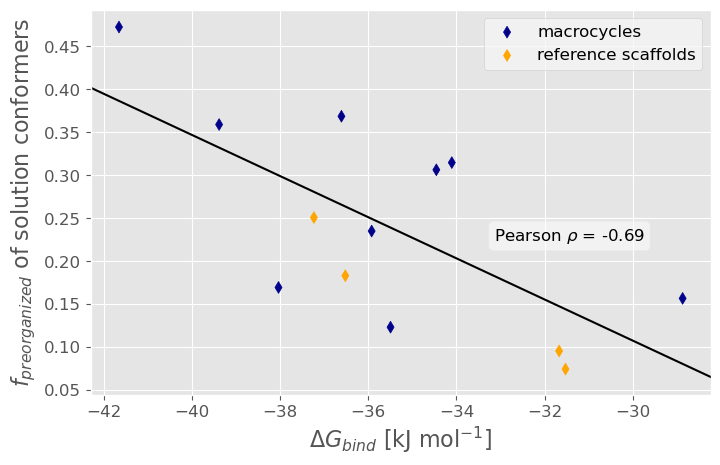

In [9]:
x = []
y = []
plt.figure(figsize=(8, 5))
for label in ['LL5', 'Acyclic']:
    labelled_data = affinity_data.loc[affinity_data.label == label]
    x.append(labelled_data["dG_FKBP51 [kJ/mol]"])
    y.append(labelled_data.allowed_ratio)
    m_or_l = 'macrocycles' if label == 'LL5' else 'reference scaffolds'
    plt.scatter(labelled_data["dG_FKBP51 [kJ/mol]"], labelled_data.allowed_ratio, label=m_or_l, color=labelled_data.color, marker='d')
pcorr = pearsonr(np.concatenate(x), np.concatenate(y))[0]

# Fit a line to the data
x = np.concatenate(x)
y = np.concatenate(y)
m, b = np.polyfit(x, y, 1)
xlims = plt.xlim()
plt.plot(np.array(xlims), m*np.array(xlims) + b, color='black')
plt.xlim(xlims)
plt.xlabel(r'$\Delta G_{bind}$ [kJ mol$^{-1}$]', fontsize=16) 
plt.ylabel(r"$f_{preorganized}$ of solution conformers", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
plt.text(0.65, 0.4, fr'Pearson $\rho$ = {pcorr:.2f}', transform=plt.gca().transAxes, bbox=props, fontsize=12)
#plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
legend = plt.legend(loc='upper right', fontsize=12)
frame = legend.get_frame()
frame.set_facecolor('whitesmoke')
plt.savefig('../figures/allowed_ratio_vs_affinity.png', bbox_inches='tight')

Correlation decreases once we include larger macrocycles

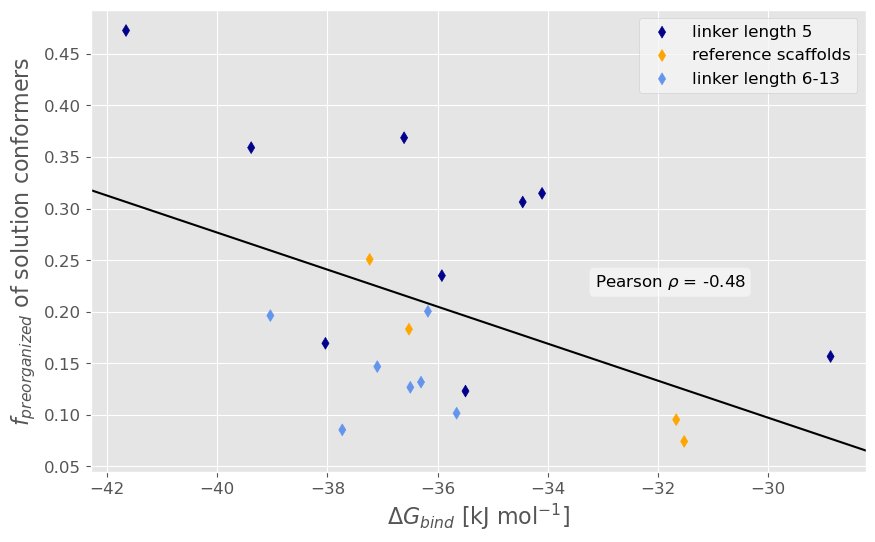

In [10]:
x = []
y = []
plt.figure(figsize=(10, 6))
for label in ['LL5', 'Acyclic', 'LL6-13']:
    labelled_data = affinity_data.loc[affinity_data.label == label]
    x.append(labelled_data["dG_FKBP51 [kJ/mol]"])
    y.append(labelled_data.allowed_ratio)
    if label == 'LL5':
        label_text = 'linker length 5'
    elif label == 'Acyclic':
        label_text = 'reference scaffolds'
    else:
        label_text = 'linker length 6-13'
    plt.scatter(labelled_data["dG_FKBP51 [kJ/mol]"], labelled_data.allowed_ratio, label=label_text, color=labelled_data.color, marker='d')
pcorr = pearsonr(np.concatenate(x), np.concatenate(y))[0]

# Fit a line to the data
x = np.concatenate(x)
y = np.concatenate(y)
m, b = np.polyfit(x, y, 1)
xlims = plt.xlim()
plt.plot(np.array(xlims), m*np.array(xlims) + b, color='black')
plt.xlim(xlims)
plt.xlabel(r'$\Delta G_{bind}$ [kJ mol$^{-1}$]', fontsize=16) 
plt.ylabel(r"$f_{preorganized}$ of solution conformers", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
plt.text(0.65, 0.4, fr'Pearson $\rho$ = {pcorr:.2f}', transform=plt.gca().transAxes, bbox=props, fontsize=12)
#plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
legend = plt.legend(loc='upper right', fontsize=12)
frame = legend.get_frame()
frame.set_facecolor('whitesmoke')
plt.savefig('../figures/allowed_ratio_vs_affinity_all.png', bbox_inches='tight')

## Part 4: Carbonyl dihedral angle / (methyl-)linker dihedral angle correlation

In [11]:
other_dihedrals = extract_other_dihedrals(solution_dir, 'md_data/other_dihedrals_solution.csv')

systems = other_dihedrals["system"].unique().tolist()
carbonyl_dihedrals = scaffold_dihedrals.pivot(index='system', columns='frame', values='angle_1').loc[systems].values
linker_dihedrals = other_dihedrals.pivot(index='system', columns='frame', values='angle_6').loc[systems].values
relevant_angles = np.swapaxes(np.array([carbonyl_dihedrals, linker_dihedrals]), 1, 2)

# Find best periodic shift for each angle
periodic_cutoffs = []
for i in range(len(relevant_angles)):
    _, periodic_cutoff = best_periodic_shift(np.concatenate(relevant_angles[i]))
    periodic_cutoffs.append(periodic_cutoff)

Reading MD data file md_data/other_dihedrals_solution.csv


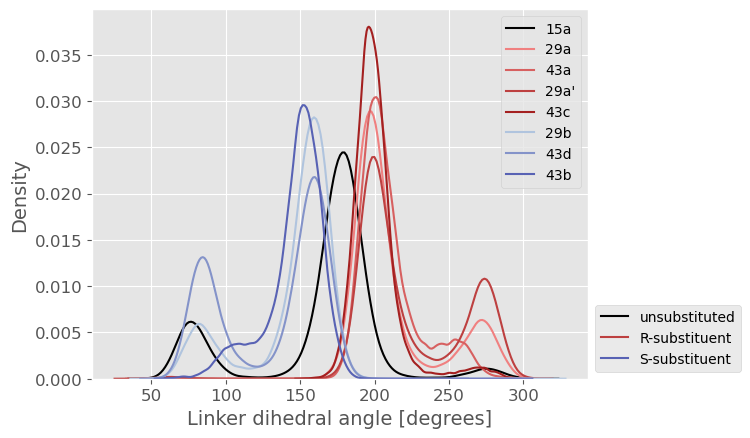

In [12]:
# Show behavior of first linker angle for each system
red_cmap = LinearSegmentedColormap.from_list('red', [(0, 'lightcoral'), (1, 'darkred')])
blue_cmap = LinearSegmentedColormap.from_list('blue', [(0, 'lightsteelblue'), (1, 'darkblue')])
red_i = 0
blue_i = 0
# custom order
ordered = ["15a", "29a", "43a", "29a'", "43c", "29b", "43d", "43b"]
for s in ordered:
    i = systems.index(s)
    shifted_angles = relevant_angles[1,:,i]
    shifted_angles[shifted_angles > periodic_cutoffs[1]] -= 360
    if s == '15a':
        sns.kdeplot(shifted_angles, bw_method=0.1, label=s, color='black')
    elif s in ["29a", "43a", "29a'", "43c"]:
        sns.kdeplot(shifted_angles, bw_method=0.1, color=red_cmap(red_i), label=s)
        red_i += 1/4
    else:
        sns.kdeplot(shifted_angles, bw_method=0.1, color=blue_cmap(blue_i), label=s)
        blue_i += 1/4
custom_lines = [plt.Line2D([0], [0], color='black'),
                plt.Line2D([0], [0], color=red_cmap(0.5)),
                plt.Line2D([0], [0], color=blue_cmap(0.5))]
leg1 = plt.legend(loc="upper right")
plt.gca().add_artist(leg1)
plt.legend(custom_lines, ['unsubstituted', 'R-substituent', 'S-substituent'], loc="lower left", bbox_to_anchor=(1, 0))
plt.xlabel("Linker dihedral angle [degrees]", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12);

/tmp/ipykernel_1145969/984201340.py:33: RuntimeWarning: divide by zero encountered in log
  logprob = np.log(probability)


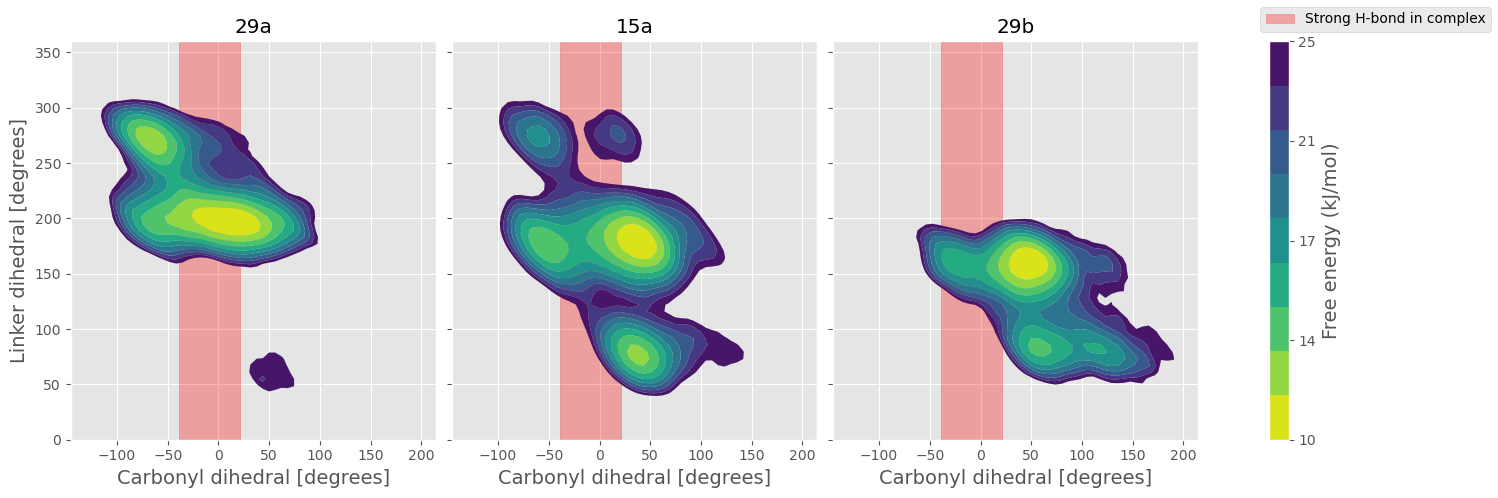

In [13]:
R = 0.00831446261815324
RT = R * 298 # kJ/mol

# Contour plot version
fig, axs = plt.subplots(ncols=3, figsize=(15,5), sharey=True)
range_cmap = LinearSegmentedColormap.from_list('range', [(0, 'white'), (1, 'red')], N=2)
light_red = range_cmap(0.5)
for i, s in enumerate(["29a", "15a", "29b"]):
    shifted_carbonyl = relevant_angles[0,:,systems.index(s)]
    shifted_carbonyl[shifted_carbonyl > periodic_cutoffs[0]] -= 360
    shifted_linker = relevant_angles[1,:,systems.index(s)]
    shifted_linker[shifted_linker > periodic_cutoffs[1]] -= 360

    max_x = periodic_cutoffs[0]
    min_x = periodic_cutoffs[0]-360
    max_y = periodic_cutoffs[1]
    min_y = periodic_cutoffs[1]-360

    if i == 0:
        #label
        axs[i].fill_betweenx([min_y, max_y], allowed_region[0], allowed_region[1], color=light_red, alpha=0.3, label="Strong H-bond in complex")
    else:
        axs[i].fill_betweenx([min_y, max_y], allowed_region[0], allowed_region[1], color=light_red, alpha=0.3)
    kde = gaussian_kde([shifted_carbonyl, shifted_linker])
    gridsize = 60
    max_free_energy= -RT*np.log(0.8/len(shifted_carbonyl)) # max free energy per bin to show
    range_x = np.linspace(min_x, max_x, gridsize)
    range_y = np.linspace(min_y, max_y, gridsize)
    X, Y = np.meshgrid(range_x, range_y)
    density = kde([X.flatten(), Y.flatten()]).reshape(X.shape)
    density = np.ma.masked_less(density, 1e-100)
    probability = density * (np.diff(range_x)[0] * np.diff(range_y)[0]) # prob per bin
    logprob = np.log(probability)
    free_energy = -RT*logprob
    levels = np.linspace(np.min(free_energy), max_free_energy, 10)
    CS = axs[i].contourf(range_x, range_y, free_energy, cmap='viridis_r', levels=levels, vmax=max_free_energy, vmin=np.min(free_energy), corner_mask=True, antialiased=True)
    axs[i].set_xlim(min_x, max_x)
    axs[i].set_ylim(min_y, max_y)
    axs[i].set_title(s)
    axs[i].set_xlabel("Carbonyl dihedral [degrees]", fontsize=14)
axs[0].set_ylabel("Linker dihedral [degrees]", fontsize=14)
fig.tight_layout()
# put one colorbar to the right of the subplots
cbar = fig.colorbar(CS, ax=axs, orientation='vertical', ticks=np.linspace(np.min(free_energy), max_free_energy, 5), format='%.0f')
cbar.set_label("Free energy (kJ/mol)", fontsize=14)
cbar.ax.tick_params(labelsize=10)
fig.legend(fontsize=10)
fig.savefig('../figures/dihedral_correlation_contour.png', bbox_inches='tight')

## Part 5: All macrocycle dihedrals (SI)

### Solution

In [14]:
acyclic_other_dihedrals = extract_other_dihedrals_acyclic(acyclic_solution_dir, 'md_data/other_dihedrals_solution_acyclic.csv')

systems = ["15a", "29a", "43a", "43c", "29a'", "29b", "43b", "43d", "1"] # Custom order

mc_dihedrals_df = pd.merge(scaffold_dihedrals, other_dihedrals, on=['system', 'frame'], suffixes=('_scaffold', '_linker'))
mc_dihedrals = [mc_dihedrals_df.pivot(index='system', columns='frame', values=col).loc[systems[:-1]].values for col in [c for c in mc_dihedrals_df.columns if 'angle' in c]]
mc_dihedrals = np.swapaxes(np.array(mc_dihedrals), 1, 2)

acyclic_dihedrals_df = pd.merge(dih_acyclic, acyclic_other_dihedrals, on=['system', 'frame'], suffixes=('_scaffold', '_linker'))
acyclic_reference_dihedrals = [acyclic_dihedrals_df.pivot(index='system', columns='frame', values=col).loc[systems[-1]].values for col in [c for c in acyclic_dihedrals_df.columns if 'angle' in c]]
acyclic_reference_dihedrals = np.squeeze(np.array(acyclic_reference_dihedrals))

scaff_angles_order = [5,3,2,15,1,0] + [i+7 for i in range(6,-1,-1)]
acyclic_ref_angles_order = [5,3,2,7,1,0]
sys_angles = np.array([mc_dihedrals[i] for i in scaff_angles_order])
acyclic_ref_angles = np.array([acyclic_reference_dihedrals[i] for i in acyclic_ref_angles_order])

n_angles, n_samples, n_systems = sys_angles.shape
n_systems += 1
periodic_cutoffs = [360]*n_angles
periodic_cutoffs[2] = 60
periodic_cutoffs[4] = 260

Reading MD data file md_data/other_dihedrals_solution_acyclic.csv


In [15]:
structures = glob.glob('../data/structures/*.pdb')
cryst_sys = [s.split("_")[1].split(".")[0] for s in structures]
cryst_angles = []
cryst_linker_angles = []
cryst_extra_angles = []
for struct in structures:
    s = pmd.load_file(struct)
    # Format path to match the one expected by get_xxx_dihedrals
    with TemporaryDirectory() as tmpdir:
        df = s.to_dataframe()
        struct_angles = []
        struct_linker_angles = []
        struct_extra_angles = []
        for chain in ["A", "B"]:
            s[((df.resname == 'PDB') | (df.resname == 'DRG')) & (df.chain == chain)].write_pdb(tmpdir+'/reference.pdb')
            md.load(tmpdir+'/reference.pdb').save(tmpdir+'/ensemble-0.dcd')
            Chem.MolToMolFile(Chem.MolFromPDBFile(tmpdir+'/reference.pdb', sanitize=False), tmpdir+'/ligand.sdf')
            struct_angles.append(get_scaffold_dihedrals(tmpdir, scaff=ALIPHATIC_SCAFFOLD))
            struct_linker_angles.append(get_linker_dihedrals(tmpdir, aliphatic_top=True))
            struct_extra_angles.append(get_extra_dihedrals(tmpdir, scaff=ALIPHATIC_SCAFFOLD))
        cryst_angles.append(struct_angles)
        cryst_linker_angles.append(struct_linker_angles)
        cryst_extra_angles.append(struct_extra_angles)

cryst_angles = np.squeeze(cryst_angles)
cryst_linker_angles = np.squeeze(cryst_linker_angles)
cryst_extra_angles = np.expand_dims(np.squeeze(cryst_extra_angles), axis=2)

cryst_sys_angles = np.concatenate([cryst_angles.T, cryst_linker_angles.T, cryst_extra_angles.T])
cryst_sys_angles = np.array([cryst_sys_angles[i] for i in scaff_angles_order])

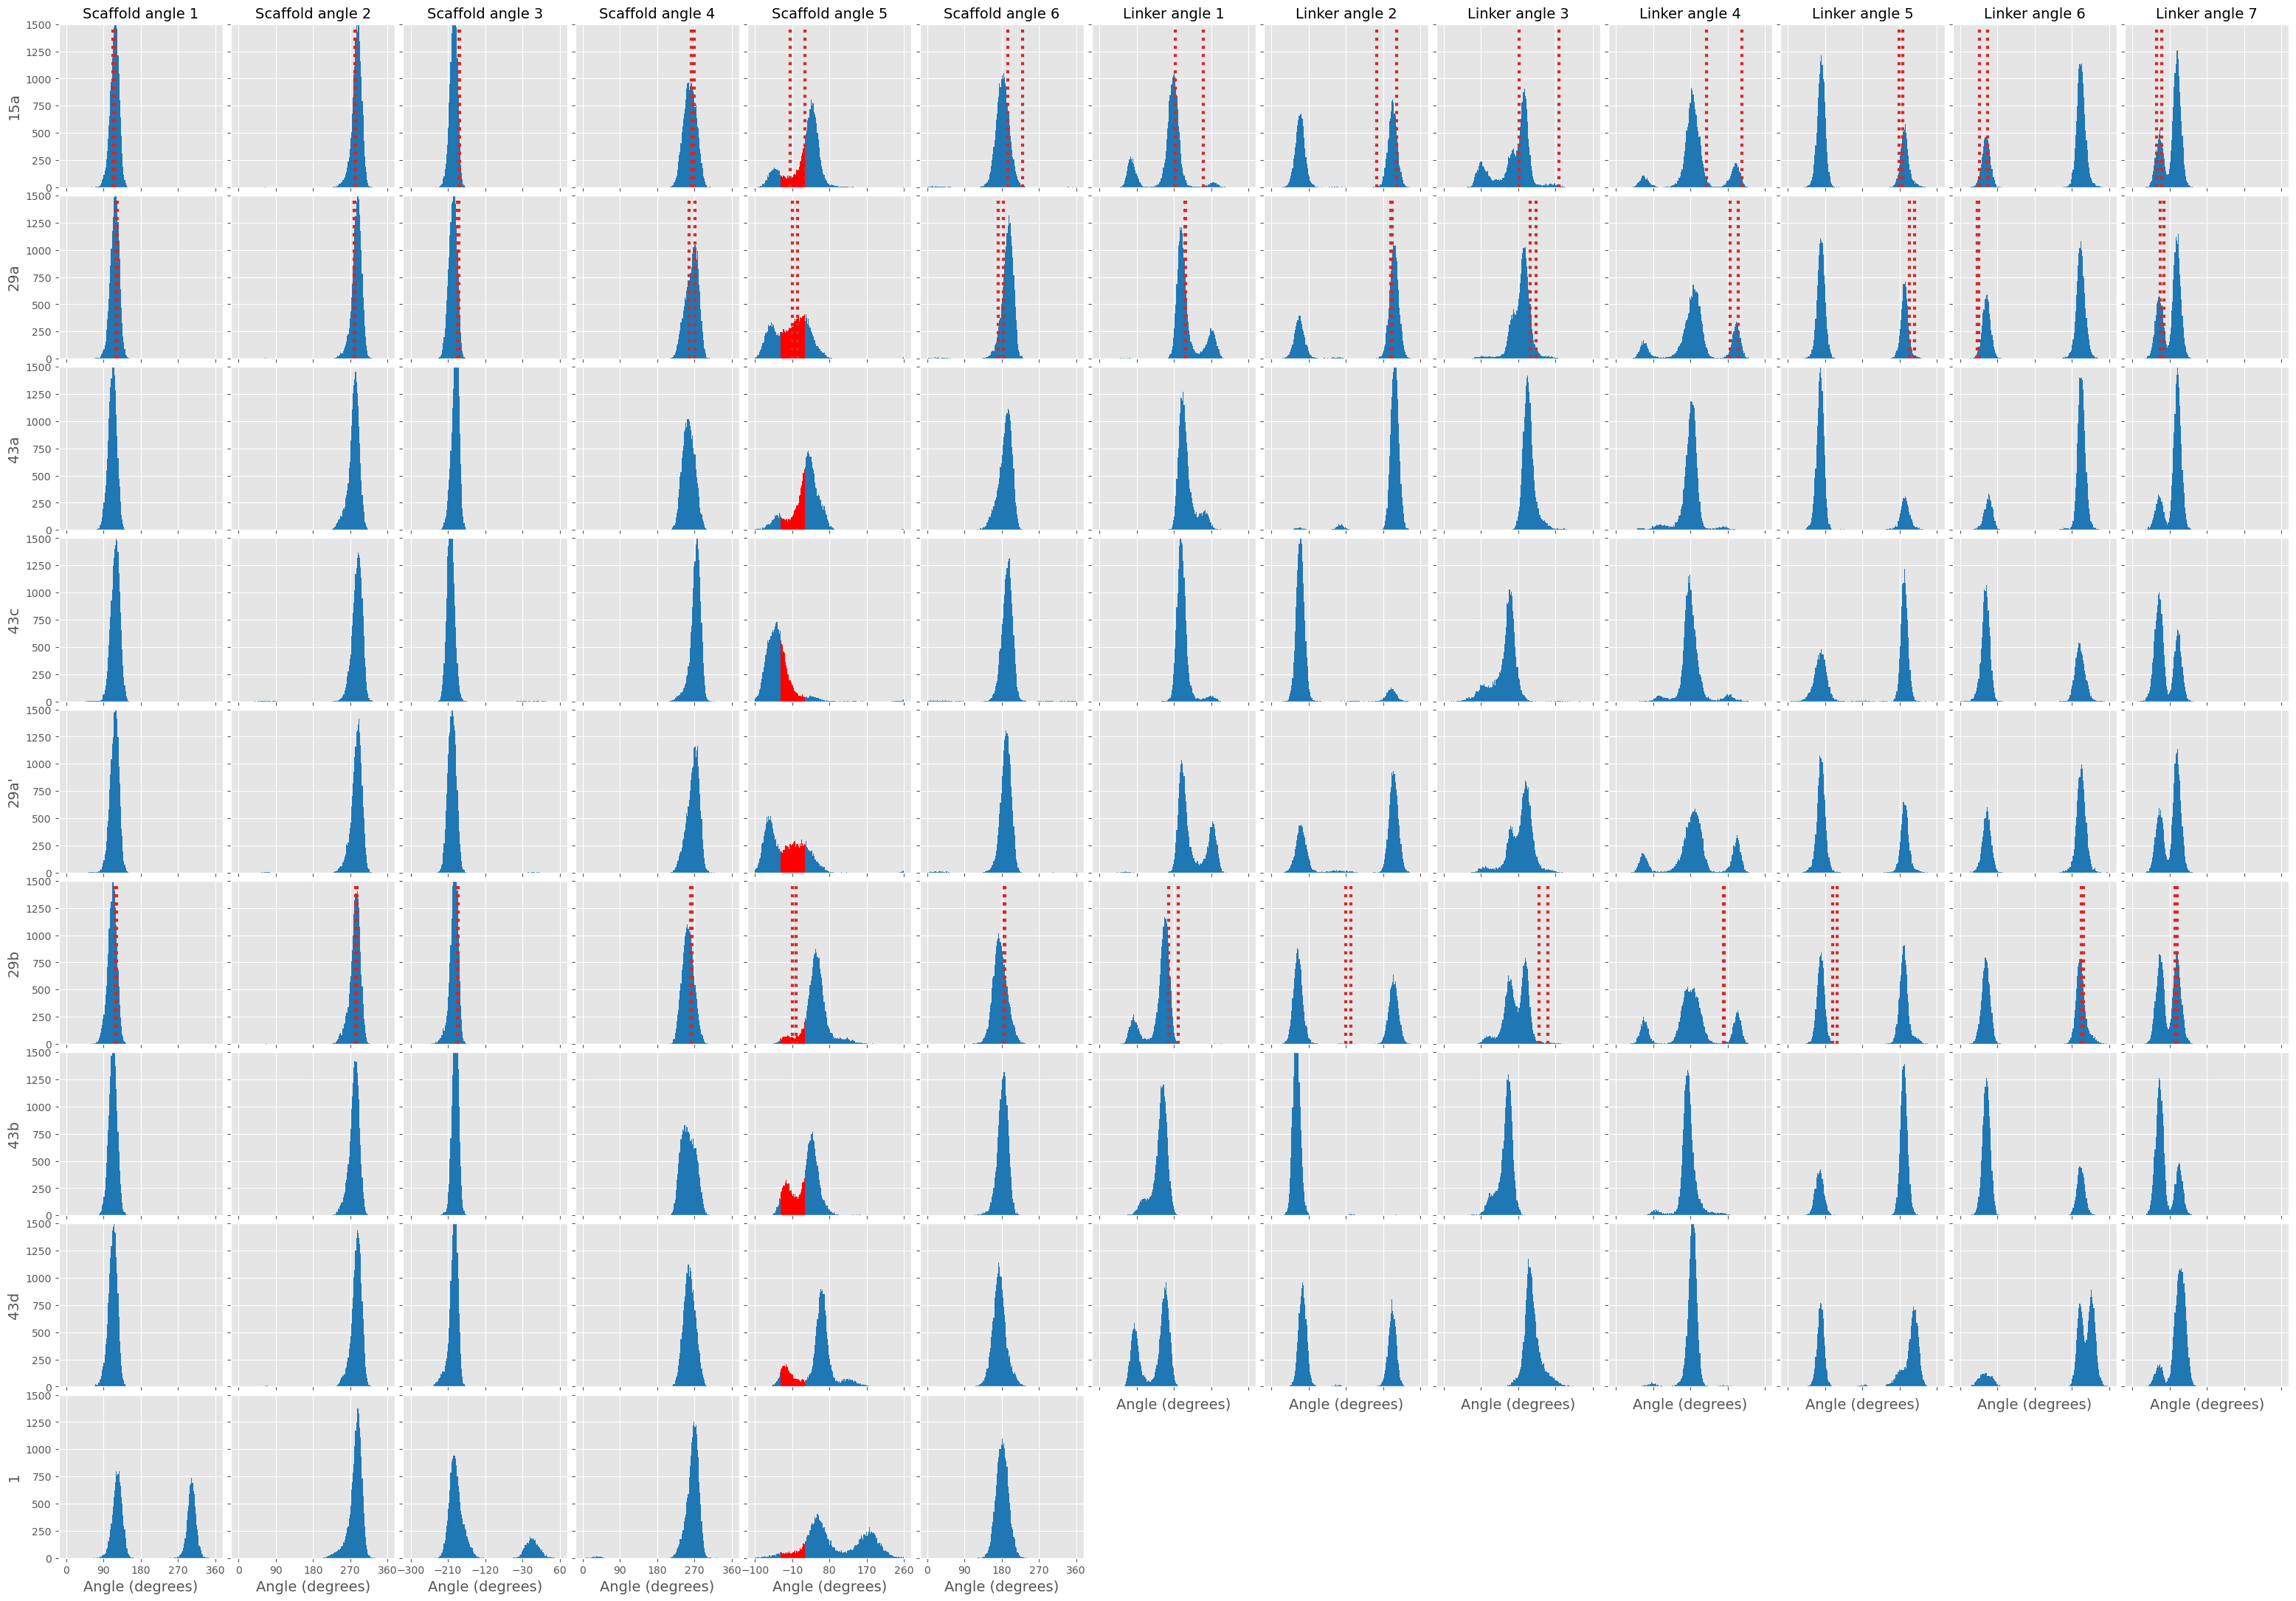

In [16]:
fontsize = 14
highlight_range = (-39, 21)

fig, axs = plt.subplots(n_systems, n_angles, figsize=(n_angles*3, n_systems*3), sharex=False, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for i, system in enumerate(systems[:-1]):
    axs[i][0].set_ylabel(system, fontsize=fontsize)
    for j, angle in enumerate(sys_angles):
        if i == 0 and j < 6:
            axs[i][j].set_title(f'Scaffold angle {j+1}', fontsize=fontsize)
        elif i == 0:
            axs[i][j].set_title(f'Linker angle {j-5}', fontsize=fontsize)
        to_plot = angle.T[i].copy()
        to_plot[np.where(to_plot > periodic_cutoffs[j])] -= 360
        _, bins, patches = axs[i][j].hist(to_plot, bins=180, range=(periodic_cutoffs[j]-360, periodic_cutoffs[j]), color='tab:blue')
        if j == 4:
            for patch, left, right in zip(patches, bins[:-1], bins[1:]):
                if highlight_range[0] <= left and right <= highlight_range[1]:
                    patch.set_facecolor('red')
        axs[i][j].set_ylim(0, 1500)
        axs[i][j].set_xticks(np.arange(periodic_cutoffs[j]-360, periodic_cutoffs[j]+1, 90), labels=[])
        if i == n_systems-2 and j > 5:
            axs[i][j].set_xticks(np.arange(periodic_cutoffs[j]-360, periodic_cutoffs[j]+1, 90))
            axs[i][j].set_xlabel('Angle (degrees)', fontsize=fontsize)
        if system in cryst_sys:
            ref_i = cryst_sys.index(system)
            ref_angles = cryst_sys_angles[j].T[ref_i]
            ref_angles[np.where(ref_angles > periodic_cutoffs[j])] -= 360
            for unit_cell_copy_angle in ref_angles:
                axs[i][j].axvline(unit_cell_copy_angle, color='tab:red', linestyle=':', linewidth=3)
for j, angle in enumerate(acyclic_ref_angles):
    axs[-1][0].set_ylabel('1', fontsize=fontsize)
    to_plot = angle.copy()
    to_plot[np.where(to_plot > periodic_cutoffs[j])] -= 360
    _, bins, patches = axs[-1][j].hist(to_plot, bins=180, range=(periodic_cutoffs[j]-360, periodic_cutoffs[j]), color='tab:blue')
    if j == 4:
        for patch, left, right in zip(patches, bins[:-1], bins[1:]):
            if highlight_range[0] <= left and right <= highlight_range[1]:
                patch.set_facecolor('red')
    axs[-1][j].set_ylim(0, 1500)
    axs[-1][j].set_xlabel('Angle (degrees)', fontsize=fontsize) 
    axs[-1][j].set_xticks(np.arange(periodic_cutoffs[j]-360, periodic_cutoffs[j]+1, 90))
for j in range(len(acyclic_ref_angles), n_angles):
    axs[-1][j].axis('off')
plt.savefig('../figures/dihedral_histograms.png', dpi=300)

### Complex

In [17]:
acyclic_scaff_dihedrals_complex = extract_scaffold_dihedrals(acyclic_complex_dir, 'md_data/scaffold_dihedrals_complex_acyclic.csv')
other_dihedrals_complex = extract_other_dihedrals(complex_dir, 'md_data/other_dihedrals_complex.csv')
acyclic_other_dihedrals_complex = extract_other_dihedrals_acyclic(acyclic_complex_dir, 'md_data/other_dihedrals_complex_acyclic.csv')

scaffold_dihedrals_complex = pd.concat([dihedrals_complex, acyclic_scaff_dihedrals_complex])

systems = ["15a", "29a", "43a", "43c", "29a'", "29b", "43b", "43d", "1"] # Custom order

mc_dihedrals_df = pd.merge(scaffold_dihedrals_complex, other_dihedrals_complex, on=['system', 'frame'], suffixes=('_scaffold', '_linker'))
mc_dihedrals = [mc_dihedrals_df.pivot(index='system', columns='frame', values=col).loc[systems[:-1]].values for col in [c for c in mc_dihedrals_df.columns if 'angle' in c]]
mc_dihedrals = np.swapaxes(np.array(mc_dihedrals), 1, 2)

acyclic_dihedrals_df = pd.merge(acyclic_scaff_dihedrals_complex, acyclic_other_dihedrals_complex, on=['system', 'frame'], suffixes=('_scaffold', '_linker'))
acyclic_reference_dihedrals = [acyclic_dihedrals_df.pivot(index='system', columns='frame', values=col).loc[systems[-1]].values for col in [c for c in acyclic_dihedrals_df.columns if 'angle' in c]]
acyclic_reference_dihedrals = np.squeeze(np.array(acyclic_reference_dihedrals))

scaff_angles_order = [5,3,2,15,1,0] + [i+7 for i in range(6,-1,-1)]
lin_ref_angles_order = [5,3,2,7,1,0]
sys_angles = np.array([mc_dihedrals[i] for i in scaff_angles_order])
lin_ref_angles = np.array([acyclic_reference_dihedrals[i] for i in lin_ref_angles_order])

n_angles, n_samples, n_systems = sys_angles.shape
n_systems += 1
periodic_cutoffs = [360]*n_angles
periodic_cutoffs[2] = 60
periodic_cutoffs[4] = 260

Reading MD data file md_data/scaffold_dihedrals_complex_acyclic.csv
Reading MD data file md_data/other_dihedrals_complex.csv
Reading MD data file md_data/other_dihedrals_complex_acyclic.csv


In [18]:
structures = glob.glob('../data/structures/*.pdb')
cryst_sys = [s.split("_")[1].split(".")[0] for s in structures]
cryst_angles = []
cryst_linker_angles = []
cryst_extra_angles = []
for struct in structures:
    s = pmd.load_file(struct)
    # Format path to match the one expected by get_xxx_dihedrals
    with TemporaryDirectory() as tmpdir:
        df = s.to_dataframe()
        struct_angles = []
        struct_linker_angles = []
        struct_extra_angles = []
        for chain in ["A", "B"]:
            s[((df.resname == 'PDB') | (df.resname == 'DRG')) & (df.chain == chain)].write_pdb(tmpdir+'/reference.pdb')
            md.load(tmpdir+'/reference.pdb').save(tmpdir+'/ensemble-0.dcd')
            Chem.MolToMolFile(Chem.MolFromPDBFile(tmpdir+'/reference.pdb', sanitize=False), tmpdir+'/ligand.sdf')
            struct_angles.append(get_scaffold_dihedrals(tmpdir, scaff=ALIPHATIC_SCAFFOLD))
            struct_linker_angles.append(get_linker_dihedrals(tmpdir, aliphatic_top=True))
            struct_extra_angles.append(get_extra_dihedrals(tmpdir, scaff=ALIPHATIC_SCAFFOLD))
        cryst_angles.append(struct_angles)
        cryst_linker_angles.append(struct_linker_angles)
        cryst_extra_angles.append(struct_extra_angles)

cryst_angles = np.squeeze(cryst_angles)
cryst_linker_angles = np.squeeze(cryst_linker_angles)
cryst_extra_angles = np.expand_dims(np.squeeze(cryst_extra_angles), axis=2)

cryst_sys_angles = np.concatenate([cryst_angles.T, cryst_linker_angles.T, cryst_extra_angles.T])
cryst_sys_angles = np.array([cryst_sys_angles[i] for i in scaff_angles_order])

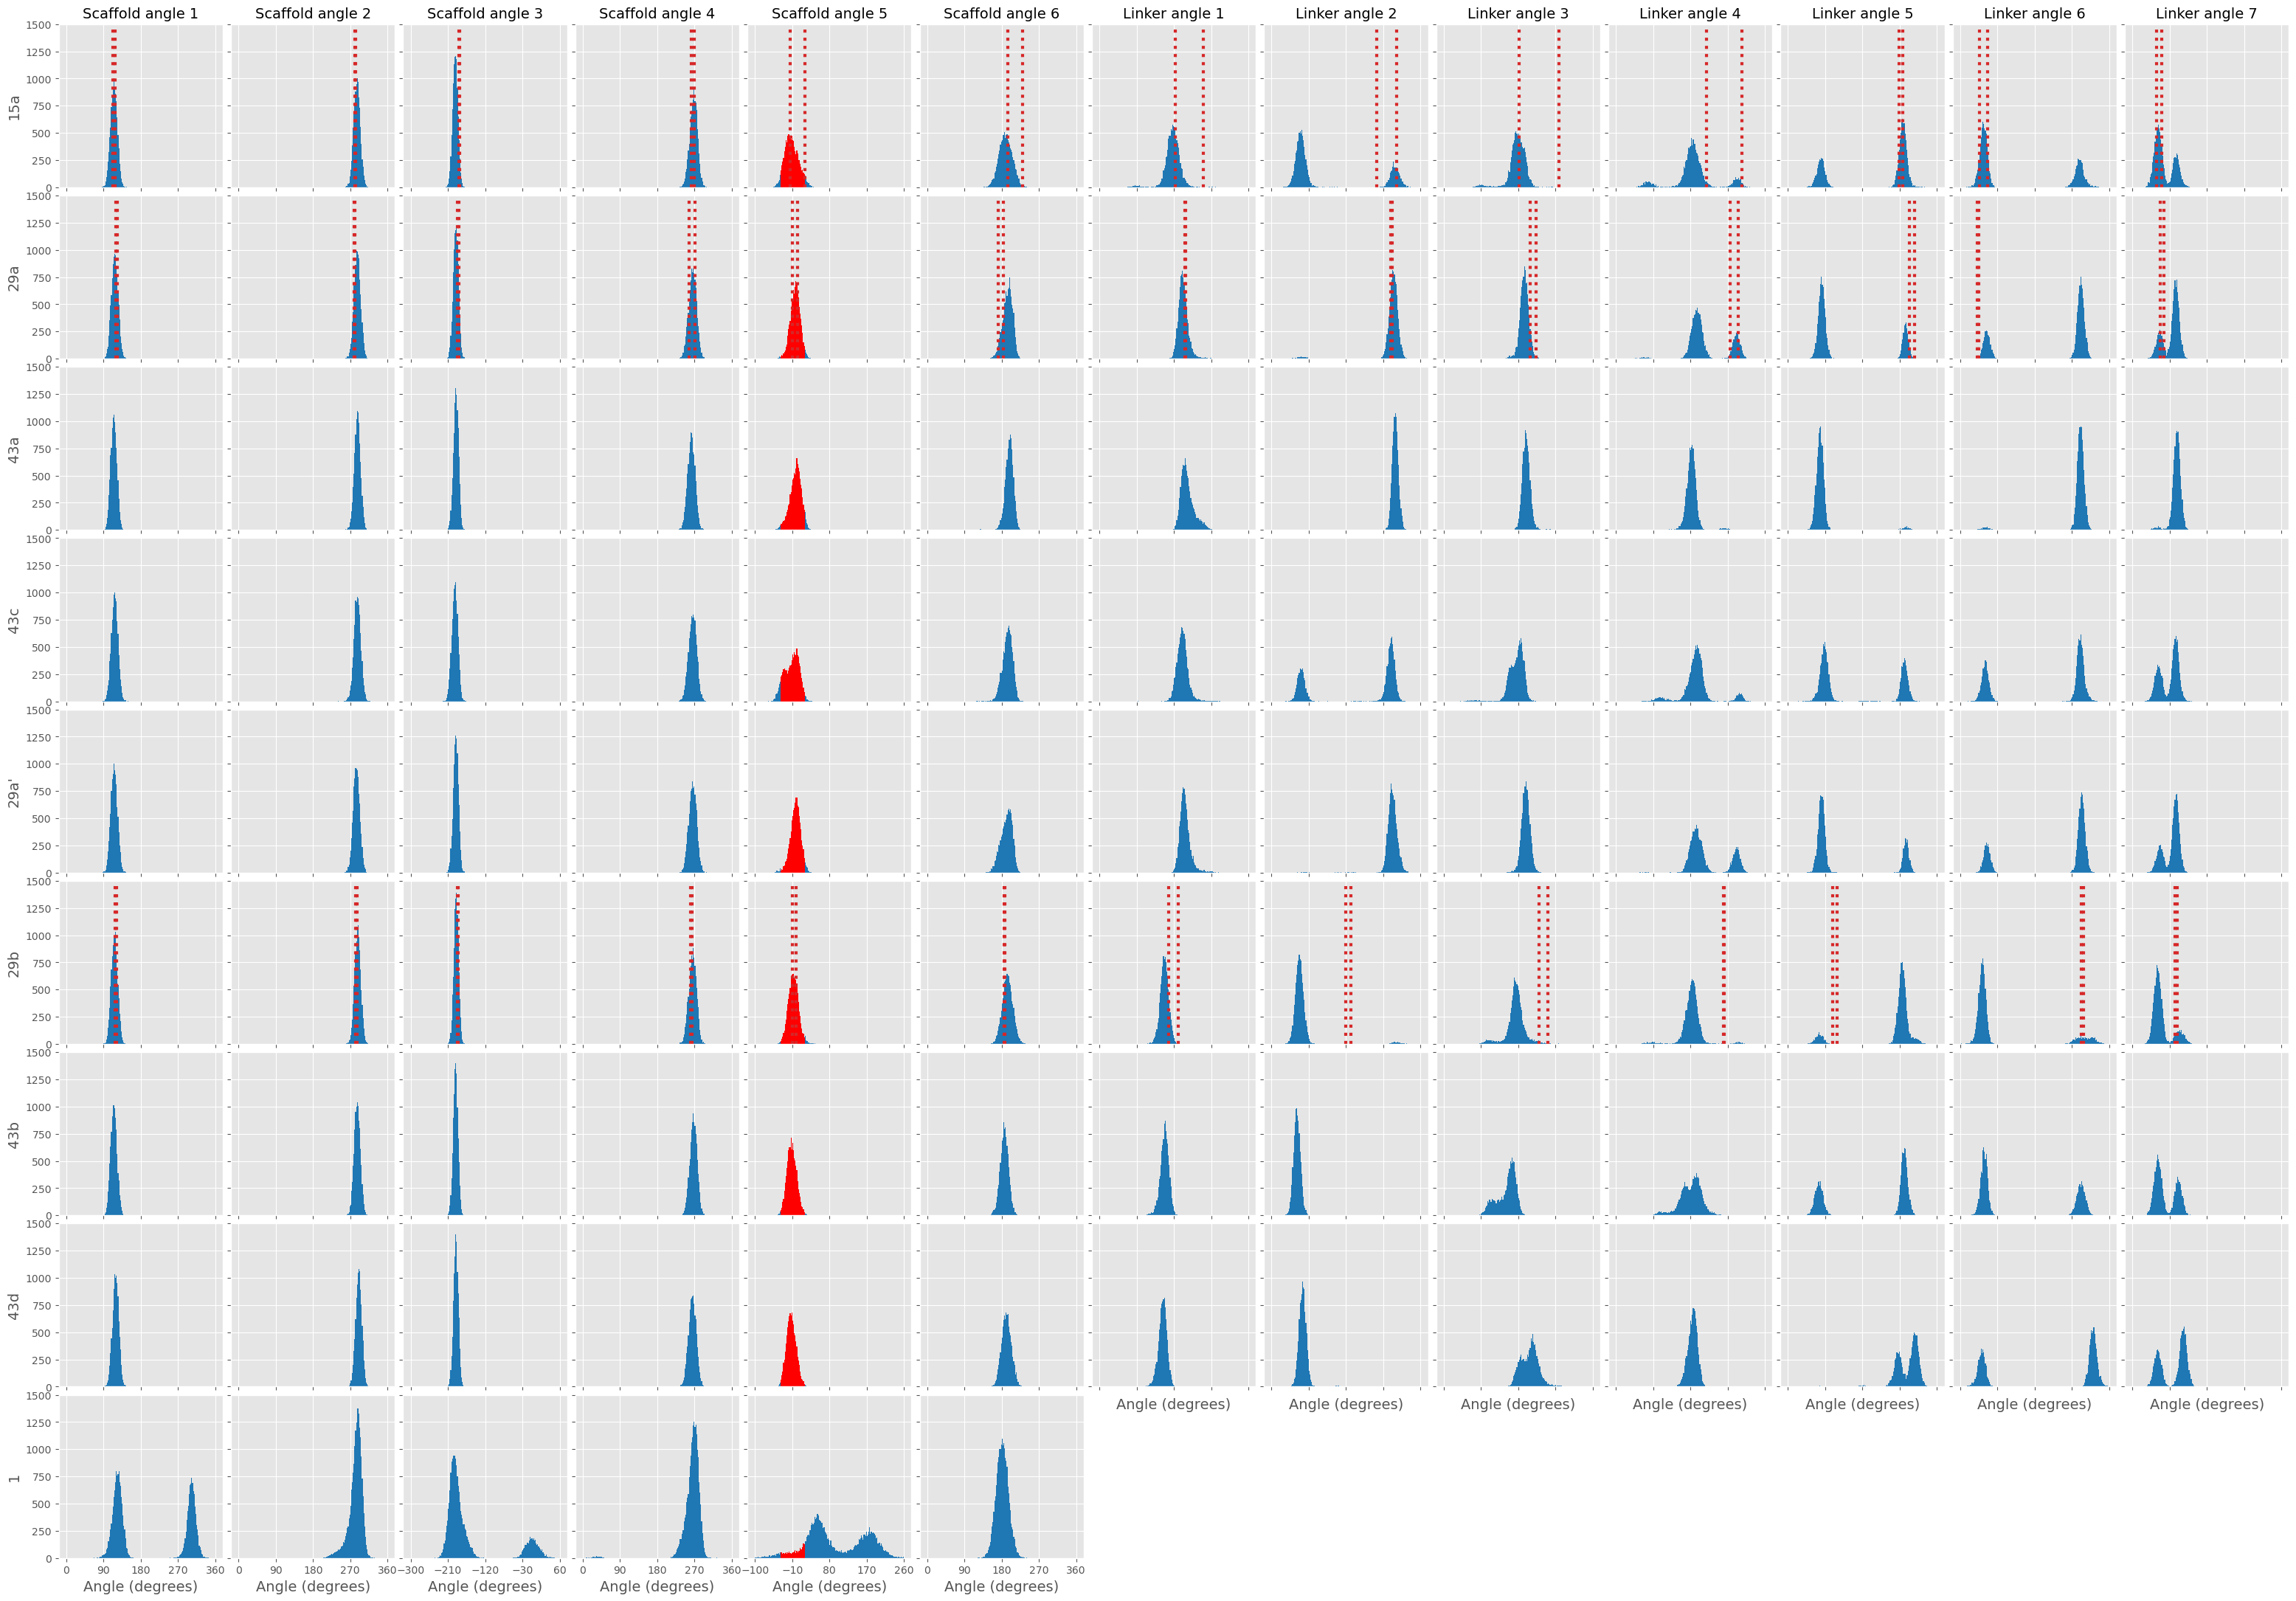

In [19]:
fontsize = 14
highlight_range = (-39, 21)

fig, axs = plt.subplots(n_systems, n_angles, figsize=(n_angles*3, n_systems*3), sharex=False, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)

for i, system in enumerate(systems[:-1]):
    axs[i][0].set_ylabel(system, fontsize=fontsize)
    for j, angle in enumerate(sys_angles):
        if i == 0 and j < 6:
            axs[i][j].set_title(f'Scaffold angle {j+1}', fontsize=fontsize)
        elif i == 0:
            axs[i][j].set_title(f'Linker angle {j-5}', fontsize=fontsize)
        to_plot = angle.T[i].copy()
        to_plot[np.where(to_plot > periodic_cutoffs[j])] -= 360
        _, bins, patches = axs[i][j].hist(to_plot, bins=180, range=(periodic_cutoffs[j]-360, periodic_cutoffs[j]), color='tab:blue')
        if j == 4:
            for patch, left, right in zip(patches, bins[:-1], bins[1:]):
                if highlight_range[0] <= left and right <= highlight_range[1]:
                    patch.set_facecolor('red')
        axs[i][j].set_ylim(0, 1500)
        axs[i][j].set_xticks(np.arange(periodic_cutoffs[j]-360, periodic_cutoffs[j]+1, 90), labels=[])
        if i == n_systems-2 and j > 5:
            axs[i][j].set_xticks(np.arange(periodic_cutoffs[j]-360, periodic_cutoffs[j]+1, 90))
            axs[i][j].set_xlabel('Angle (degrees)', fontsize=fontsize)
        if system in cryst_sys:
            ref_i = cryst_sys.index(system)
            ref_angles = cryst_sys_angles[j].T[ref_i]
            ref_angles[np.where(ref_angles > periodic_cutoffs[j])] -= 360
            for unit_cell_copy_angle in ref_angles:
                axs[i][j].axvline(unit_cell_copy_angle, color='tab:red', linestyle=':', linewidth=3)
for j, angle in enumerate(acyclic_ref_angles):
    axs[-1][0].set_ylabel('1', fontsize=fontsize)
    to_plot = angle.copy()
    to_plot[np.where(to_plot > periodic_cutoffs[j])] -= 360
    _, bins, patches = axs[-1][j].hist(to_plot, bins=180, range=(periodic_cutoffs[j]-360, periodic_cutoffs[j]), color='tab:blue')
    if j == 4:
        for patch, left, right in zip(patches, bins[:-1], bins[1:]):
            if highlight_range[0] <= left and right <= highlight_range[1]:
                patch.set_facecolor('red')
    axs[-1][j].set_ylim(0, 1500)
    axs[-1][j].set_xlabel('Angle (degrees)', fontsize=fontsize) 
    axs[-1][j].set_xticks(np.arange(periodic_cutoffs[j]-360, periodic_cutoffs[j]+1, 90))
for j in range(len(acyclic_ref_angles), n_angles):
    axs[-1][j].axis('off')
plt.savefig('../figures/dihedral_histograms_complex.png', dpi=300)

## Part 6: Convergence analysis (SI)

### Solution

Calculating convergence for 1
Number of PCs to explain 90.0% variance: 6
Calculating convergence for 10a
Number of PCs to explain 90.0% variance: 12
Calculating convergence for 10b
Number of PCs to explain 90.0% variance: 5
Calculating convergence for 10c
Number of PCs to explain 90.0% variance: 6
Calculating convergence for 10d
Number of PCs to explain 90.0% variance: 6
Calculating convergence for 15a
Number of PCs to explain 90.0% variance: 9
Calculating convergence for 15b
Number of PCs to explain 90.0% variance: 6
Calculating convergence for 15c
Number of PCs to explain 90.0% variance: 6
Calculating convergence for 29a
Number of PCs to explain 90.0% variance: 8
Calculating convergence for 29a'
Number of PCs to explain 90.0% variance: 9
Calculating convergence for 29b
Number of PCs to explain 90.0% variance: 8
Calculating convergence for 29c
Number of PCs to explain 90.0% variance: 5
Calculating convergence for 29d
Number of PCs to explain 90.0% variance: 4
Calculating convergence f

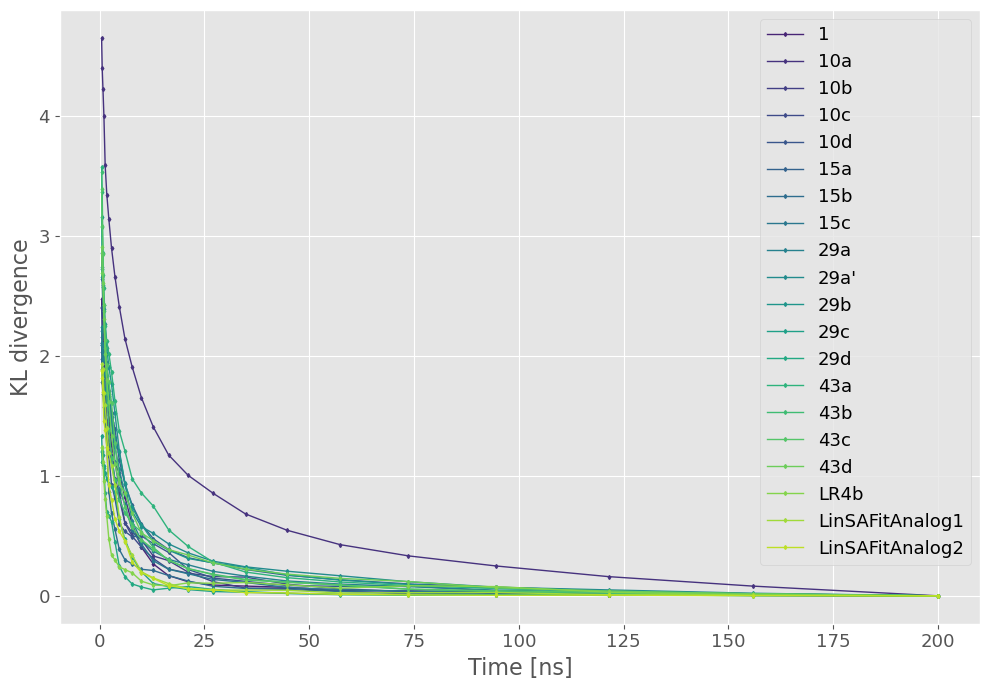

In [20]:
all_dihedrals = pd.merge(scaffold_dihedrals, other_dihedrals, on=['system', 'frame'], suffixes=('_scaffold', '_linker'), how='outer')
systems = all_dihedrals["system"].unique().tolist()

cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0.1, 0.9, len(systems))]
plt.figure(figsize=(10, 7))
for i, system in enumerate(systems):
    print(f"Calculating convergence for {system}")
    angle_cols = [c for c in all_dihedrals.columns if c.startswith("angle_")]
    angles = all_dihedrals[all_dihedrals["system"] == system][angle_cols].values
    # remove NaN columns
    not_all_NaNs = ~np.all(np.isnan(angles), axis=tuple(range(angles.ndim-1)))
    angles = np.deg2rad(angles[..., not_all_NaNs])
    times, Dcurve = convergence_curve(angles, variance_to_explain=0.9, min_samples=50, num_points=25)
    # Frames saved every 10 ps
    times = times / 100  # Convert to ns
    plt.plot(times, Dcurve, marker='d', lw=1, label=system, ms=2, color=colors[i])
plt.xlabel("Time [ns]", fontsize=16)
plt.ylabel("KL divergence", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig('../figures/convergence_curve.png', bbox_inches='tight')

### Complex

Calculating convergence for 1
Number of PCs to explain 90.0% variance: 3
Calculating convergence for 10a
Number of PCs to explain 90.0% variance: 7
Calculating convergence for 10b
Number of PCs to explain 90.0% variance: 6
Calculating convergence for 10c
Number of PCs to explain 90.0% variance: 6
Calculating convergence for 10d
Number of PCs to explain 90.0% variance: 7
Calculating convergence for 15a
Number of PCs to explain 90.0% variance: 6
Calculating convergence for 15b
Number of PCs to explain 90.0% variance: 6
Calculating convergence for 15c
Number of PCs to explain 90.0% variance: 7
Calculating convergence for 29a
Number of PCs to explain 90.0% variance: 5
Calculating convergence for 29a'
Number of PCs to explain 90.0% variance: 5
Calculating convergence for 29b
Number of PCs to explain 90.0% variance: 8
Calculating convergence for 29c
Number of PCs to explain 90.0% variance: 6
Calculating convergence for 29d
Number of PCs to explain 90.0% variance: 6
Calculating convergence fo

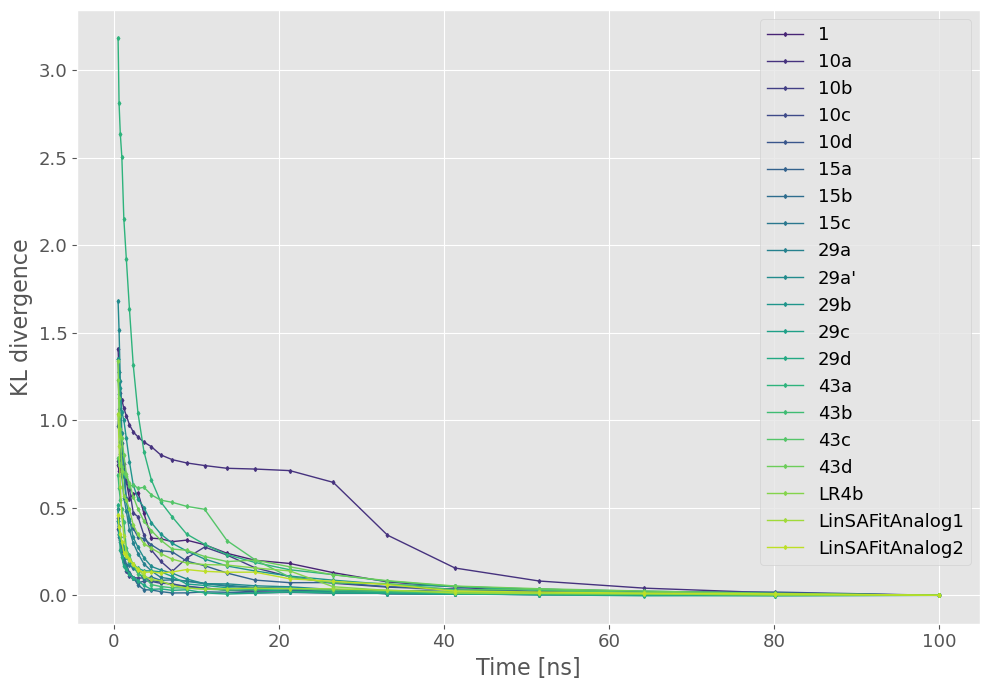

In [21]:
all_dihedrals = pd.merge(scaffold_dihedrals_complex, other_dihedrals_complex, on=['system', 'frame'], suffixes=('_scaffold', '_linker'), how='outer')
systems = all_dihedrals["system"].unique().tolist()

cmap = plt.get_cmap('viridis')
colors = [cmap(i) for i in np.linspace(0.1, 0.9, len(systems))]
plt.figure(figsize=(10, 7))
for i, system in enumerate(systems):
    print(f"Calculating convergence for {system}")
    angle_cols = [c for c in all_dihedrals.columns if c.startswith("angle_")]
    angles = all_dihedrals[all_dihedrals["system"] == system][angle_cols].values
    # remove NaN columns
    not_all_NaNs = ~np.all(np.isnan(angles), axis=tuple(range(angles.ndim-1)))
    angles = np.deg2rad(angles[..., not_all_NaNs])
    times, Dcurve = convergence_curve(angles, variance_to_explain=0.9, min_samples=50, num_points=25)
    # Frames saved every 10 ps
    times = times / 100  # Convert to ns
    plt.plot(times, Dcurve, marker='d', lw=1, label=system, ms=2, color=colors[i])
plt.xlabel("Time [ns]", fontsize=16)
plt.ylabel("KL divergence", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=13)
plt.tight_layout()
plt.savefig('../figures/convergence_curve_complex.png', bbox_inches='tight')

## Part 7: Dihedral angle correlation in complex

Here we see that the effect of the linker methylation cannot be observed from the simulations of the ligands in complex with FKBP51, as all ligands have similar bound conformations

In [22]:
systems = other_dihedrals_complex["system"].unique().tolist()
carbonyl_dihedrals = scaffold_dihedrals_complex.pivot(index='system', columns='frame', values='angle_1').loc[systems].values
linker_dihedrals = other_dihedrals_complex.pivot(index='system', columns='frame', values='angle_6').loc[systems].values
relevant_angles = np.swapaxes(np.array([carbonyl_dihedrals, linker_dihedrals]), 1, 2)

# Find best periodic shift for each angle
periodic_cutoffs = []
for i in range(len(relevant_angles)):
    _, periodic_cutoff = best_periodic_shift(np.concatenate(relevant_angles[i]))
    periodic_cutoffs.append(periodic_cutoff)

/tmp/ipykernel_1145969/3527244924.py:33: RuntimeWarning: divide by zero encountered in log
  logprob = np.log(probability)


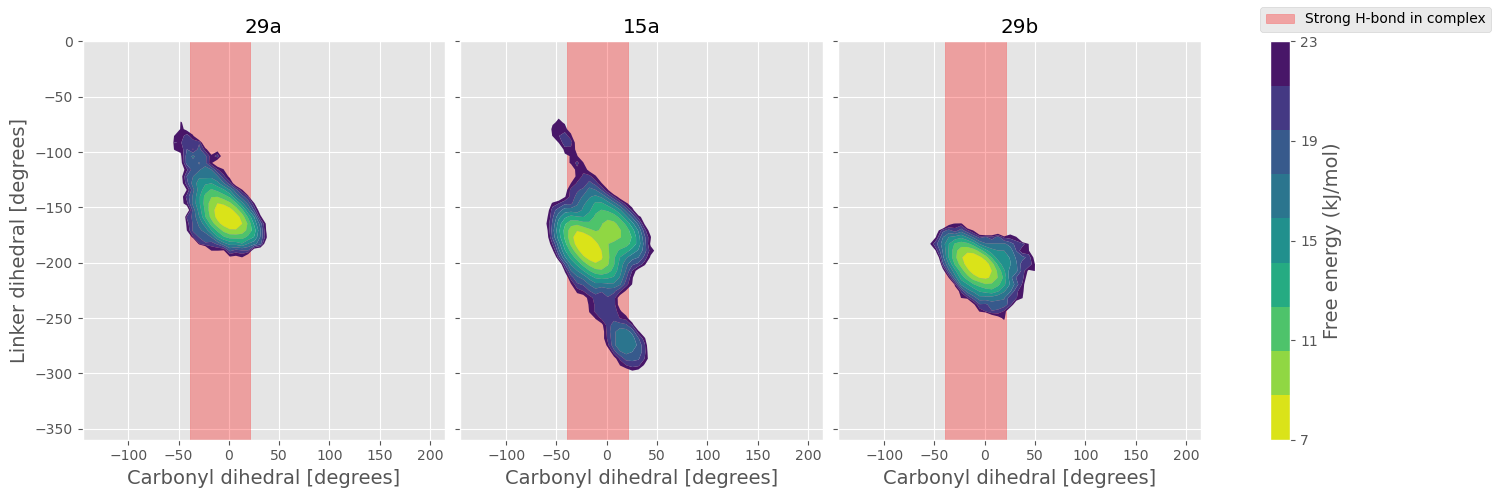

In [23]:
R = 0.00831446261815324
RT = R * 298 # kJ/mol

# Contour plot version
fig, axs = plt.subplots(ncols=3, figsize=(15,5), sharey=True)
range_cmap = LinearSegmentedColormap.from_list('range', [(0, 'white'), (1, 'red')], N=2)
light_red = range_cmap(0.5)
for i, s in enumerate(["29a", "15a", "29b"]):
    shifted_carbonyl = relevant_angles[0,:,systems.index(s)]
    shifted_carbonyl[shifted_carbonyl > periodic_cutoffs[0]] -= 360
    shifted_linker = relevant_angles[1,:,systems.index(s)]
    shifted_linker[shifted_linker > periodic_cutoffs[1]] -= 360

    max_x = periodic_cutoffs[0]
    min_x = periodic_cutoffs[0]-360
    max_y = periodic_cutoffs[1]
    min_y = periodic_cutoffs[1]-360

    if i == 0:
        #label
        axs[i].fill_betweenx([min_y, max_y], allowed_region[0], allowed_region[1], color=light_red, alpha=0.3, label="Strong H-bond in complex")
    else:
        axs[i].fill_betweenx([min_y, max_y], allowed_region[0], allowed_region[1], color=light_red, alpha=0.3)
    kde = gaussian_kde([shifted_carbonyl, shifted_linker])
    gridsize = 60
    max_free_energy= -RT*np.log(0.8/len(shifted_carbonyl)) # max free energy per bin to show
    range_x = np.linspace(min_x, max_x, gridsize)
    range_y = np.linspace(min_y, max_y, gridsize)
    X, Y = np.meshgrid(range_x, range_y)
    density = kde([X.flatten(), Y.flatten()]).reshape(X.shape)
    density = np.ma.masked_less(density, 1e-100)
    probability = density * (np.diff(range_x)[0] * np.diff(range_y)[0]) # prob per bin
    logprob = np.log(probability)
    free_energy = -RT*logprob
    levels = np.linspace(np.min(free_energy), max_free_energy, 10)
    CS = axs[i].contourf(range_x, range_y, free_energy, cmap='viridis_r', levels=levels, vmax=max_free_energy, vmin=np.min(free_energy), corner_mask=True, antialiased=True)
    axs[i].set_xlim(min_x, max_x)
    axs[i].set_ylim(min_y, max_y)
    axs[i].set_title(s)
    axs[i].set_xlabel("Carbonyl dihedral [degrees]", fontsize=14)
axs[0].set_ylabel("Linker dihedral [degrees]", fontsize=14)
fig.tight_layout()
# put one colorbar to the right of the subplots
cbar = fig.colorbar(CS, ax=axs, orientation='vertical', ticks=np.linspace(np.min(free_energy), max_free_energy, 5), format='%.0f')
cbar.set_label("Free energy (kJ/mol)", fontsize=14)
cbar.ax.tick_params(labelsize=10)
fig.legend(fontsize=10)
fig.savefig('../figures/dihedral_correlation_contour_complex.png', bbox_inches='tight')